In [1]:
pip install duckdb

   ---------------------------------------- 0.0/13.1 MB ? eta -:--:--
   ------------ --------------------------- 4.2/13.1 MB 31.5 MB/s eta 0:00:01
   ------------------------------------ --- 12.1/13.1 MB 34.4 MB/s eta 0:00:01
   ---------------------------------------- 13.1/13.1 MB 31.5 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import duckdb
import pandas as pd

# Connect
con = duckdb.connect()

Funnel Conversion Analysis

In [10]:
# --------------------------------------------------
# 1. FUNNEL ANALYSIS (USER-PRODUCT LEVEL)
# --------------------------------------------------

# This script calculates a basic funnel: view → cart → purchase
# Note: Because we group by user_id and product_id, the funnel does NOT count raw events.
# Instead, it records whether each user–product pair reached each stage at least once.
# So if a user views the same product 10 times, it still counts as 1 view.
# The funnel measures unique user–product interactions.

# Deduplicated funnel (unique user-product interactions)

funnel_unique = con.execute("""
    SELECT 
        user_id,
        product_id,
        MAX(event_type = 'view')::INT AS viewed,
        MAX(event_type = 'cart')::INT AS carted,
        MAX(event_type = 'purchase')::INT AS purchased
    FROM read_parquet('*.parquet')
    GROUP BY user_id, product_id
""").df()

views_u = funnel_unique['viewed'].sum()
carts_u = funnel_unique['carted'].sum()
purchases_u = funnel_unique['purchased'].sum()

print("\n--- Deduplicated Funnel (User-Product) ---")
print(f"Views: {views_u}")
print(f"Carts: {carts_u}")
print(f"Purchases: {purchases_u}")
print(f"View → Cart: {carts_u / views_u:.4f}")
print(f"Cart → Purchase: {purchases_u / carts_u:.4f}")
print(f"View → Purchase: {purchases_u / views_u:.4f}")


--- Deduplicated Funnel (User-Product) ---
Views: 138424780
Carts: 6050223
Purchases: 3050314
View → Cart: 0.0437
Cart → Purchase: 0.5042
View → Purchase: 0.0220


In [7]:
summary_df = pd.DataFrame([{
    "views_unique": views_u,
    "carts_unique": carts_u,
    "purchases_unique": purchases_u,
    "view_to_cart": carts_u / views_u,
    "cart_to_purchase": purchases_u / carts_u,
    "view_to_purchase": purchases_u / views_u
}])

summary_df.to_csv("unique_pairs_funnel_summary.csv", index=False)

In [11]:
# Raw event funnel (event counts)

events = con.execute("""
    SELECT 
        SUM(event_type = 'view')::INT AS views,
        SUM(event_type = 'cart')::INT AS carts,
        SUM(event_type = 'purchase')::INT AS purchases
    FROM read_parquet('*.parquet')
""").df()

views_r = int(events['views'][0])
carts_r = int(events['carts'][0])
purchases_r = int(events['purchases'][0])

print("\n--- Raw Event Funnel ---")
print(f"Views: {views_r}")
print(f"Carts: {carts_r}")
print(f"Purchases: {purchases_r}")
print(f"View → Cart: {carts_r / views_r:.4f}")
print(f"Cart → Purchase: {purchases_r / carts_r:.4f}")
print(f"View → Purchase: {purchases_r / views_r:.4f}")


--- Raw Event Funnel ---
Views: 253857834
Carts: 11870371
Purchases: 4150415
View → Cart: 0.0468
Cart → Purchase: 0.3496
View → Purchase: 0.0163


In [8]:
summary_df = pd.DataFrame([{
    "views_unique": views_r,
    "carts_unique": carts_r,
    "purchases_unique": purchases_r,
    "view_to_cart": carts_r / views_r,
    "cart_to_purchase": purchases_r / carts_r,
    "view_to_purchase": purchases_r / views_r
}])

summary_df.to_csv("all_pairs_funnel_summary.csv", index=False)

In [12]:
view_to_cart = carts_u / views_u if views_u else 0
cart_to_purchase = purchases_u / carts_u if carts_u else 0

drop_view_cart = 1 - view_to_cart
drop_cart_purchase = 1 - cart_to_purchase

print("\n--- Drop-off Rates (Deduplicated Funnel) ---")
print(f"Drop-off View → Cart: {drop_view_cart * 100:.2f}%")
print(f"Drop-off Cart → Purchase: {drop_cart_purchase * 100:.2f}%")


--- Drop-off Rates (Deduplicated Funnel) ---
Drop-off View → Cart: 95.63%
Drop-off Cart → Purchase: 49.58%


In [12]:
dropoff_df = pd.DataFrame([{
    "dropoff_view_to_cart_pct": drop_view_cart * 100,
    "dropoff_cart_to_purchase_pct": drop_cart_purchase * 100
}])

# Save to CSV
dropoff_df.to_csv("unique_pairs_funnel_dropoff.csv", index=False)

In [13]:
view_to_cart_r = carts_r / views_r if views_r else 0
cart_to_purchase_r = purchases_r / carts_r if carts_r else 0

drop_view_cart_r = 1 - view_to_cart_r
drop_cart_purchase_r = 1 - cart_to_purchase_r

print("\n--- Drop-off Rates (Deduplicated Funnel) ---")
print(f"Drop-off View → Cart: {drop_view_cart_r * 100:.2f}%")
print(f"Drop-off Cart → Purchase: {drop_cart_purchase_r * 100:.2f}%")


--- Drop-off Rates (Deduplicated Funnel) ---
Drop-off View → Cart: 95.32%
Drop-off Cart → Purchase: 65.04%


In [11]:
# Create a DataFrame
dropoff_df = pd.DataFrame([{
    "dropoff_view_to_cart_pct": drop_view_cart_r * 100,
    "dropoff_cart_to_purchase_pct": drop_cart_purchase_r * 100
}])

# Save to CSV
dropoff_df.to_csv("all_pairs_funnel_dropoff.csv", index=False)

In [14]:
# Category level funnel
# Each count means: How many unique user–product interactions in this category reached each stage at least once?
# This is typically called a:
# conversion funnel
# unique interaction funnel
# entity-level funnel (user–product) aggregated by category

category_funnel = con.execute("""
    SELECT 
        category_code,
        SUM(viewed) AS viewed,
        SUM(carted) AS carted,
        SUM(purchased) AS purchased
    FROM (
        SELECT 
            user_id,
            product_id,
            category_code,
            MAX(event_type = 'view')::INT AS viewed,
            MAX(event_type = 'cart')::INT AS carted,
            MAX(event_type = 'purchase')::INT AS purchased
        FROM read_parquet('*.parquet')
        GROUP BY user_id, product_id, category_code
    ) AS t
    GROUP BY category_code
""").df()

import pandas as pd

# Safe conversion rates
category_funnel["view_to_cart"] = category_funnel["carted"] / category_funnel["viewed"].replace(0, pd.NA)
category_funnel["cart_to_purchase"] = category_funnel["purchased"] / category_funnel["carted"].replace(0, pd.NA)

print("\n--- Category Funnel (Top 10 by Purchases) ---")
print(category_funnel.sort_values("purchased", ascending=False).head(10))


--- Category Funnel (Top 10 by Purchases) ---
                        category_code      viewed     carted  purchased  \
109          construction.tools.light  17416297.0  1400884.0   727666.0   
98             electronics.smartphone  12687652.0   838488.0   502543.0   
65                            Unknown  28651602.0   930564.0   476539.0   
128       electronics.audio.headphone   3868973.0   191477.0    97743.0   
121                     sport.bicycle   2887780.0   186895.0    84810.0   
0                  electronics.clocks   4332422.0   151720.0    76390.0   
64       appliances.personal.massager   2692598.0   144378.0    66256.0   
15      appliances.environment.vacuum   2567004.0   123062.0    63743.0   
14                      apparel.shoes   4566384.0   144559.0    61803.0   
58   appliances.kitchen.refrigerators   3831814.0   132647.0    61700.0   

     view_to_cart  cart_to_purchase  
109      0.080435          0.519433  
98       0.066087          0.599344  
65       0.03

In [17]:
category_funnel.to_csv("category_funnel.csv", index=False)

In [15]:
# Brand level funnel

brand_funnel = con.execute("""
WITH funnel_brand AS (
    SELECT 
        user_id,
        product_id,
        brand,
        MAX(event_type = 'view')::INT AS viewed,
        MAX(event_type = 'cart')::INT AS carted,
        MAX(event_type = 'purchase')::INT AS purchased
    FROM read_parquet('*.parquet')
    GROUP BY user_id, product_id, brand
),

brand_counts AS (
    SELECT
        brand,
        SUM(viewed) AS viewed,
        SUM(carted) AS carted,
        SUM(purchased) AS purchased
    FROM funnel_brand
    GROUP BY brand
),

brand_avg_price AS (
    SELECT
        brand,
        AVG(price) AS avg_price
    FROM read_parquet('*.parquet')
    GROUP BY brand
)

SELECT
    b.brand,
    b.viewed,
    b.carted,
    b.purchased,
    (b.carted / NULLIF(b.viewed, 0)) AS view_to_cart,
    (b.purchased / NULLIF(b.carted, 0)) AS cart_to_purchase,
    (b.purchased / NULLIF(b.viewed, 0)) AS view_to_purchase,
    (1 - b.carted / NULLIF(b.viewed, 0)) AS drop_view_cart,
    (1 - b.purchased / NULLIF(b.carted, 0)) AS drop_cart_purchase,
    a.avg_price
FROM brand_counts b
LEFT JOIN brand_avg_price a
ON b.brand = a.brand
ORDER BY drop_view_cart
""").df()

print(brand_funnel.head(10))

       brand  viewed  carted  purchased  view_to_cart  cart_to_purchase  \
0    actimel     2.0     2.0        0.0      1.000000          0.000000   
1   miniland     1.0     1.0        0.0      1.000000          0.000000   
2    ekobike     1.0     1.0        0.0      1.000000          0.000000   
3     qarqus     4.0     3.0        1.0      0.750000          0.333333   
4  naturella     8.0     6.0        2.0      0.750000          0.333333   
5      ulker    11.0     8.0        4.0      0.727273          0.500000   
6  a-product    14.0    10.0        6.0      0.714286          0.600000   
7      orbit     7.0     5.0        3.0      0.714286          0.600000   
8      comet    37.0    26.0        8.0      0.702703          0.307692   
9     benuta     3.0     2.0        1.0      0.666667          0.500000   

   view_to_purchase  drop_view_cart  drop_cart_purchase   avg_price  
0          0.000000        0.000000            1.000000    0.480000  
1          0.000000        0.00000

In [16]:
brand_funnel.to_csv("brand_funnel.csv", index=False)

In [18]:
# Hourly funnel table

hourly_funnel = con.execute("""
WITH funnel_hour AS (
    SELECT 
        user_id,
        product_id,
        hour,
        MAX(event_type = 'view')::INT AS viewed,
        MAX(event_type = 'cart')::INT AS carted,
        MAX(event_type = 'purchase')::INT AS purchased
    FROM read_parquet('*.parquet')
    GROUP BY user_id, product_id, hour
),

hourly_counts AS (
    SELECT
        hour,
        SUM(viewed) AS viewed,
        SUM(carted) AS carted,
        SUM(purchased) AS purchased
    FROM funnel_hour
    GROUP BY hour
)

SELECT
    hour,
    viewed,
    carted,
    purchased,
    (carted / NULLIF(viewed, 0)) AS view_to_cart,
    (purchased / NULLIF(carted, 0)) AS cart_to_purchase,
    (purchased / NULLIF(viewed, 0)) AS view_to_purchase
FROM hourly_counts
ORDER BY hour
""").df()

print(hourly_funnel)

hourly_funnel.to_csv("hourly_funnel.csv", index=False)

    hour      viewed    carted  purchased  view_to_cart  cart_to_purchase  \
0      0   3974503.0  172114.0    93260.0      0.043305          0.541850   
1      1   4604222.0  197875.0   110013.0      0.042977          0.555972   
2      2   5525947.0  245878.0   130155.0      0.044495          0.529348   
3      3   6704059.0  323319.0   172618.0      0.048227          0.533894   
4      4   7730450.0  395496.0   214677.0      0.051161          0.542804   
5      5   8390923.0  449862.0   237635.0      0.053613          0.528240   
6      6   8830398.0  481593.0   246831.0      0.054538          0.512530   
7      7   9014849.0  488080.0   252724.0      0.054142          0.517792   
8      8   9410653.0  493447.0   252290.0      0.052435          0.511281   
9      9   9836519.0  488191.0   246519.0      0.049630          0.504964   
10    10  10010882.0  472691.0   233248.0      0.047218          0.493447   
11    11  10008619.0  445498.0   214564.0      0.044511          0.481627   

Brand Impact

In [25]:
brand_analysis = con.execute("""
WITH brand_counts AS (
    SELECT
        brand,
        COUNT(*) FILTER (WHERE event_type = 'view') AS view,
        COUNT(*) FILTER (WHERE event_type = 'cart') AS cart,
        COUNT(*) FILTER (WHERE event_type = 'purchase') AS purchase
    FROM read_parquet('*.parquet')
    GROUP BY brand
),

brand_prices AS (
    SELECT
        brand,
        AVG(price) AS avg_price
    FROM read_parquet('*.parquet')
    GROUP BY brand
)

SELECT
    b.brand,
    b.view,
    b.cart,
    b.purchase,
    (b.purchase / NULLIF(b.view, 0)) AS conversion_rate,
    (1 - b.cart / NULLIF(b.view, 0)) AS drop_view_cart,
    (1 - b.purchase / NULLIF(b.cart, 0)) AS drop_cart_purchase,
    p.avg_price
FROM brand_counts b
LEFT JOIN brand_prices p
ON b.brand = p.brand
ORDER BY conversion_rate DESC
""").df()

print(brand_analysis.head(10))

brand_analysis.to_csv("brand_analysis.csv", index=False)

         brand  view  cart  purchase  conversion_rate  drop_view_cart  \
0       dotemu     2     0         1         0.500000        1.000000   
1        orbit     7     8         3         0.428571       -0.142857   
2    a-product    17    25         6         0.352941       -0.470588   
3          yan    17    12         6         0.352941        0.294118   
4       benuta     3     4         1         0.333333       -0.333333   
5          bio     3     2         1         0.333333        0.333333   
6        ulker    12    15         4         0.333333       -0.250000   
7       tassay     7     6         2         0.285714        0.142857   
8  capri-sonne     4     4         1         0.250000        0.000000   
9      chocair     8     6         2         0.250000        0.250000   

   drop_cart_purchase  avg_price  
0                 NaN  17.990000  
1            0.625000   0.413333  
2            0.760000   1.134792  
3            0.500000   3.766857  
4            0.750000

Cart Abandonment by Category

In [ ]:
# Of all user–product pairs that were added to cart at least once, what fraction did not result in a purchase?

result = con.execute("""
WITH funnel AS (
    SELECT 
        user_id,
        product_id,
        MAX(event_type = 'cart')::INT AS carted,
        MAX(event_type = 'purchase')::INT AS purchased
    FROM read_parquet('*.parquet')
    GROUP BY user_id, product_id
)

SELECT
    SUM(carted) AS total_carts,
    SUM(purchased) AS total_purchases,
    (SUM(carted) - SUM(purchased)) / NULLIF(SUM(carted), 0) AS abandonment_rate
FROM funnel
""").df()

print(result)

   total_carts  total_purchases  abandonment_rate
0    6050223.0        3050314.0          0.495834


In [22]:
result.to_csv("cart_abandonment.csv", index=False)

In [25]:
print(category_funnel.columns)

Index(['category_code', 'viewed', 'carted', 'purchased', 'view_to_cart',
       'cart_to_purchase'],
      dtype='object')


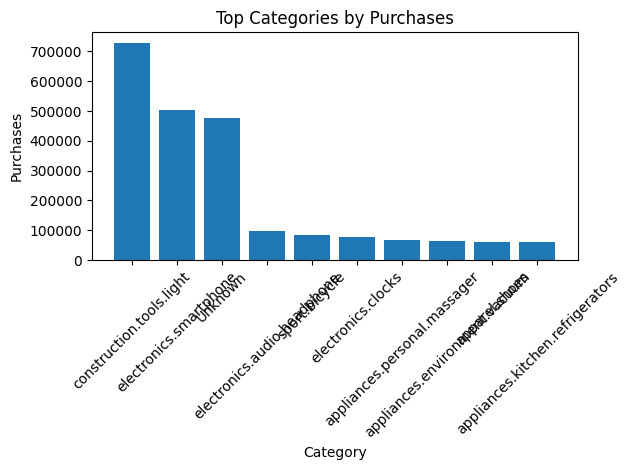

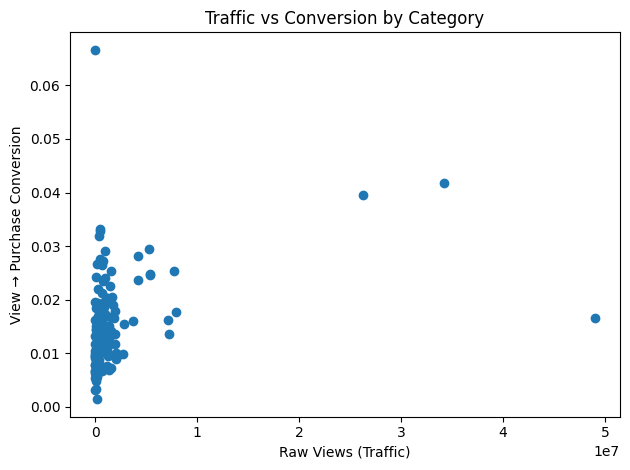

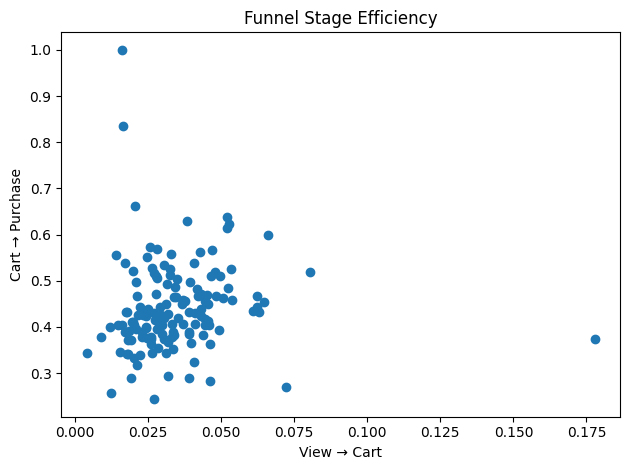

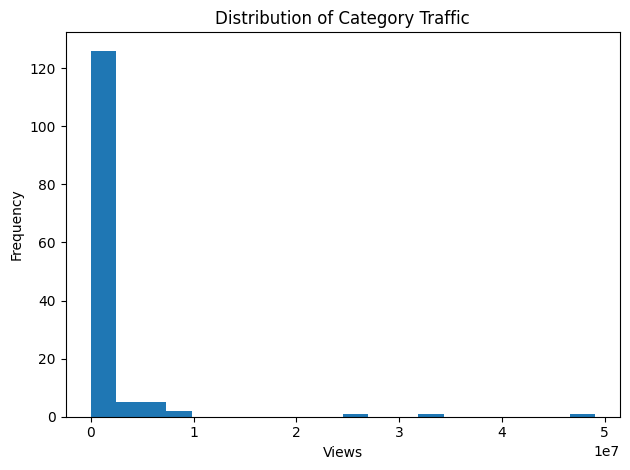

                        category_code      viewed     carted  purchased  \
109          construction.tools.light  17416297.0  1400884.0   727666.0   
98             electronics.smartphone  12687652.0   838488.0   502543.0   
65                            Unknown  28651602.0   930564.0   476539.0   
128       electronics.audio.headphone   3868973.0   191477.0    97743.0   
121                     sport.bicycle   2887780.0   186895.0    84810.0   
0                  electronics.clocks   4332422.0   151720.0    76390.0   
64       appliances.personal.massager   2692598.0   144378.0    66256.0   
15      appliances.environment.vacuum   2567004.0   123062.0    63743.0   
14                      apparel.shoes   4566384.0   144559.0    61803.0   
58   appliances.kitchen.refrigerators   3831814.0   132647.0    61700.0   

     view_to_cart  cart_to_purchase  views_raw  carts_raw  purchases_raw  \
109      0.080435          0.519433   34268921    3052619        1084779   
98       0.066087     

In [22]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 2. GET RAW EVENT COUNTS FROM DUCKDB
# --------------------------------------------------
event_counts = con.execute("""
    SELECT
        category_code,
        COUNT(*) FILTER (WHERE event_type = 'view') AS views_raw,
        COUNT(*) FILTER (WHERE event_type = 'cart') AS carts_raw,
        COUNT(*) FILTER (WHERE event_type = 'purchase') AS purchases_raw
    FROM read_parquet('*.parquet')
    GROUP BY category_code
""").df()


# --------------------------------------------------
# 3. MERGE DEDUPED + RAW DATA
# --------------------------------------------------
combined = category_funnel.merge(event_counts, on='category_code', how='left')

# Fill missing values
combined[['views_raw','carts_raw','purchases_raw']] = combined[
    ['views_raw','carts_raw','purchases_raw']
].fillna(0)


# --------------------------------------------------
# 4. DERIVE ADDITIONAL METRICS
# --------------------------------------------------

# Deduplicated funnel metric (if not already present)
combined['view_to_purchase'] = combined['purchased'] / combined['viewed'].replace(0, pd.NA)

# Raw event-based ratios
combined['event_view_to_cart'] = combined['carts_raw'] / combined['views_raw'].replace(0, pd.NA)
combined['event_cart_to_purchase'] = combined['purchases_raw'] / combined['carts_raw'].replace(0, pd.NA)

combined['traffic'] = combined['views_raw']
combined['conversion'] = combined['view_to_purchase']


# --------------------------------------------------
# 5. SORT FOR ANALYSIS
# --------------------------------------------------
combined_sorted = combined.sort_values('purchased', ascending=False)


# --------------------------------------------------
# 6. PLOTS
# --------------------------------------------------

# ---- Plot 1: Top categories by purchases ----
plt.figure()
top_categories = combined_sorted.head(10)
plt.bar(top_categories['category_code'], top_categories['purchased'])
plt.xticks(rotation=45)
plt.title("Top Categories by Purchases")
plt.xlabel("Category")
plt.ylabel("Purchases")
plt.tight_layout()
plt.show()


# ---- Plot 2: Traffic vs Conversion ----
plt.figure()
plt.scatter(combined['views_raw'], combined['conversion'])

plt.xlabel("Raw Views (Traffic)")
plt.ylabel("View → Purchase Conversion")
plt.title("Traffic vs Conversion by Category")
plt.tight_layout()
plt.show()


# ---- Plot 3: Funnel Stage Efficiency ----
plt.figure()
plt.scatter(combined['view_to_cart'], combined['cart_to_purchase'])

plt.xlabel("View → Cart")
plt.ylabel("Cart → Purchase")
plt.title("Funnel Stage Efficiency")
plt.tight_layout()
plt.show()


# ---- Plot 4: Traffic distribution ----
plt.figure()
plt.hist(combined['views_raw'], bins=20)
plt.title("Distribution of Category Traffic")
plt.xlabel("Views")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 7. INSPECT FINAL TABLE
# --------------------------------------------------
print(combined_sorted.head(10))

In [29]:
combined_sorted.to_csv("combined_funnel_for_category.csv", index=False)

Temporal Behavior

In [7]:
weekend_funnel = con.execute("""
WITH base AS (
    SELECT 
        user_id,
        product_id,
        event_time,
        CASE 
            WHEN EXTRACT(dow FROM event_time) IN (0, 6) THEN 1 
            ELSE 0 
        END AS is_weekend,
        event_type
    FROM read_parquet('*.parquet')
),

funnel AS (
    SELECT 
        user_id,
        product_id,
        is_weekend,
        MAX(event_type = 'view')::INT AS viewed,
        MAX(event_type = 'cart')::INT AS carted,
        MAX(event_type = 'purchase')::INT AS purchased
    FROM base
    GROUP BY user_id, product_id, is_weekend
),

aggregated AS (
    SELECT
        is_weekend,
        SUM(viewed) AS views,
        SUM(carted) AS carts,
        SUM(purchased) AS purchases
    FROM funnel
    GROUP BY is_weekend
)

SELECT
    CASE 
        WHEN is_weekend = 1 THEN 'Weekend'
        ELSE 'Weekday'
    END AS period,

    views,
    carts,
    purchases,

    (carts * 1.0 / NULLIF(views, 0)) AS view_to_cart,
    (purchases * 1.0 / NULLIF(carts, 0)) AS cart_to_purchase,
    (purchases * 1.0 / NULLIF(views, 0)) AS view_to_purchase

FROM aggregated
ORDER BY is_weekend
""").df()

print(weekend_funnel)

    period       views      carts  purchases  view_to_cart  cart_to_purchase  \
0  Weekday  98374050.0  4241337.0  2072193.0      0.043114          0.488571   
1  Weekend  46978681.0  2153134.0  1125412.0      0.045832          0.522686   

   view_to_purchase  
0          0.021064  
1          0.023956  


In [4]:
weekend_funnel.to_csv("weekend_funnel.csv", index=False)

In [8]:
hourly_weekend_funnel = con.execute("""
WITH base AS (
    SELECT 
        user_id,
        product_id,
        event_time,
        EXTRACT(hour FROM event_time) AS hour,
        CASE 
            WHEN EXTRACT(dow FROM event_time) IN (0, 6) THEN 1 
            ELSE 0 
        END AS is_weekend,
        event_type
    FROM read_parquet('*.parquet')
),

funnel AS (
    -- Deduplicate at user-product-hour-weekend level
    SELECT 
        user_id,
        product_id,
        hour,
        is_weekend,
        MAX(event_type = 'view')::INT AS viewed,
        MAX(event_type = 'cart')::INT AS carted,
        MAX(event_type = 'purchase')::INT AS purchased
    FROM base
    GROUP BY user_id, product_id, hour, is_weekend
),

aggregated AS (
    -- Aggregate per hour + weekend flag
    SELECT
        hour,
        is_weekend,
        SUM(viewed) AS views,
        SUM(carted) AS carts,
        SUM(purchased) AS purchases
    FROM funnel
    GROUP BY hour, is_weekend
)

SELECT
    hour,
    CASE 
        WHEN is_weekend = 1 THEN 'Weekend'
        ELSE 'Weekday'
    END AS period,

    views,
    carts,
    purchases,

    (carts * 1.0 / NULLIF(views, 0)) AS view_to_cart,
    (purchases * 1.0 / NULLIF(carts, 0)) AS cart_to_purchase,
    (purchases * 1.0 / NULLIF(views, 0)) AS view_to_purchase

FROM aggregated
ORDER BY hour, is_weekend
""").df()

print(hourly_weekend_funnel)

    hour   period      views     carts  purchases  view_to_cart  \
0      0  Weekday  2652197.0  107086.0    62225.0      0.040376   
1      0  Weekend  1351972.0   66365.0    31939.0      0.049088   
2      1  Weekday  3058342.0  124755.0    72223.0      0.040792   
3      1  Weekend  1581587.0   74656.0    38926.0      0.047203   
4      2  Weekday  3785542.0  162127.0    88419.0      0.042828   
5      2  Weekend  1753565.0   84343.0    42400.0      0.048098   
6      3  Weekday  4623458.0  218619.0   114891.0      0.047285   
7      3  Weekend  2162315.0  108788.0    60109.0      0.050311   
8      4  Weekday  5338651.0  268671.0   140146.0      0.050326   
9      4  Weekend  2459062.0  130209.0    76725.0      0.052951   
10     5  Weekday  5758228.0  302200.0   154875.0      0.052481   
11     5  Weekend  2704686.0  151749.0    85160.0      0.056106   
12     6  Weekday  6000136.0  320378.0   160110.0      0.053395   
13     6  Weekend  2904823.0  165503.0    89134.0      0.05697

In [6]:
hourly_weekend_funnel.to_csv("hourly_weekend_funnel.csv", index=False)

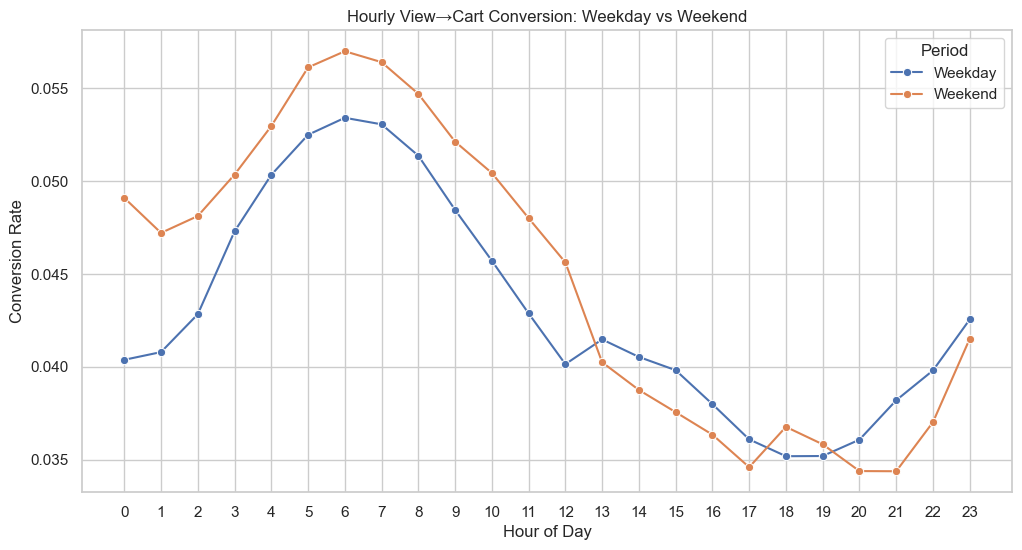

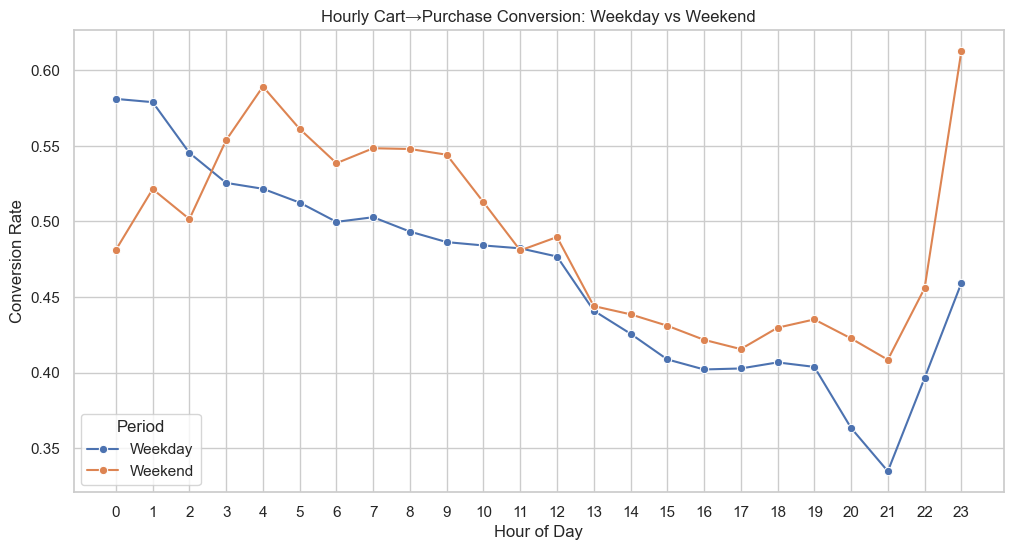

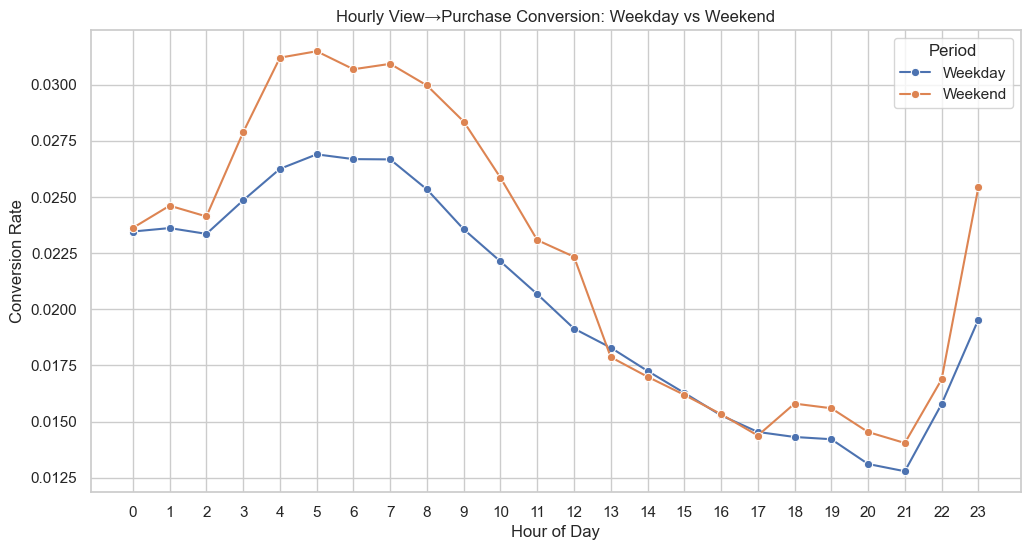

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
stages = ['view_to_cart','cart_to_purchase','view_to_purchase']
titles = ['View→Cart Conversion','Cart→Purchase Conversion','View→Purchase Conversion']

for stage, title in zip(stages, titles):
    plt.figure(figsize=(12,6))
    sns.lineplot(data=hourly_weekend_funnel, x='hour', y=stage, hue='period', marker='o')
    plt.title(f'Hourly {title}: Weekday vs Weekend')
    plt.xlabel('Hour of Day')
    plt.ylabel('Conversion Rate')
    plt.xticks(range(0,24))
    plt.legend(title='Period')
    plt.show()

In [4]:
monthly_funnel = con.execute("""
SELECT
    DATE_TRUNC('month', event_time) AS month,
    COUNT(*) FILTER (WHERE event_type = 'view') AS views,
    COUNT(*) FILTER (WHERE event_type = 'cart') AS carts,
    COUNT(*) FILTER (WHERE event_type = 'purchase') AS purchases,
    COUNT(*) FILTER (WHERE event_type = 'cart') * 1.0 / NULLIF(COUNT(*) FILTER (WHERE event_type = 'view'), 0) AS view_to_cart,
    COUNT(*) FILTER (WHERE event_type = 'purchase') * 1.0 / NULLIF(COUNT(*) FILTER (WHERE event_type = 'cart'), 0) AS cart_to_purchase,
    COUNT(*) FILTER (WHERE event_type = 'purchase') * 1.0 / NULLIF(COUNT(*) FILTER (WHERE event_type = 'view'), 0) AS view_to_purchase
FROM read_parquet('*.parquet')
GROUP BY month
ORDER BY month
""").df()

print(monthly_funnel)

                      month     views    carts  purchases  view_to_cart  \
0 2019-09-01 00:00:00-04:00     71384      860       1171      0.012048   
1 2019-10-01 00:00:00-04:00  40743409   926702     743229      0.022745   
2 2019-11-01 00:00:00-04:00  63268513  3023326     915388      0.047786   
3 2019-12-01 00:00:00-05:00  25126299  1223514     406272      0.048695   
4 2020-01-01 00:00:00-05:00  22340215  1030387     321355      0.046123   
5 2020-02-01 00:00:00-05:00  20500912  1295111     418182      0.063173   
6 2020-03-01 00:00:00-05:00  19515571  1103584     378059      0.056549   
7 2020-04-01 00:00:00-04:00  62291531  3266887     966759      0.052445   

   cart_to_purchase  view_to_purchase  
0          1.361628          0.016404  
1          0.802015          0.018242  
2          0.302775          0.014468  
3          0.332053          0.016169  
4          0.311878          0.014385  
5          0.322893          0.020398  
6          0.342574          0.019372  
7   

In [5]:
monthly_funnel.to_csv("monthly_funnel.csv", index=False)

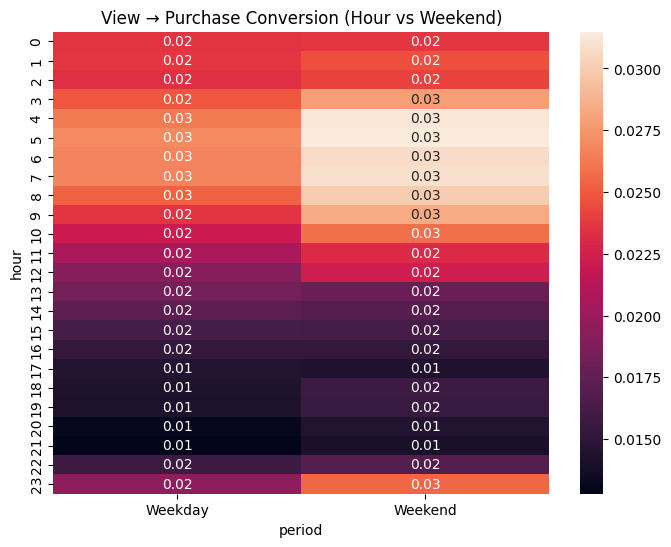

In [9]:
# Identify peak conversion hours
# Compare weekday vs weekend behavior visually
import seaborn as sns
import matplotlib.pyplot as plt

pivot = hourly_weekend_funnel.pivot_table(
    index='hour',
    columns='period',
    values='view_to_purchase'
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".2f")
plt.title("View → Purchase Conversion (Hour vs Weekend)")
plt.show()

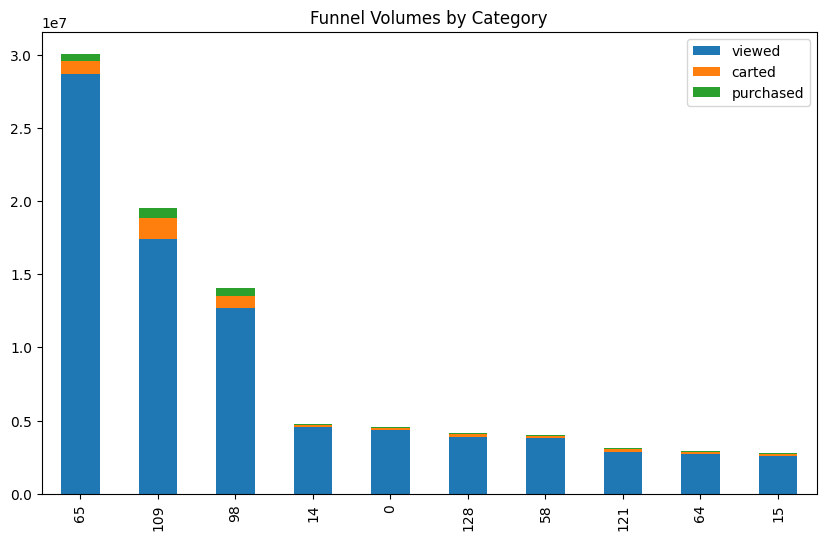

In [17]:
# Where drop-offs occur in absolute terms
# Funnel shape per segment
df_plot = category_funnel.sort_values('viewed', ascending=False).head(10)

df_plot[['viewed','carted','purchased']].plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)
plt.title("Funnel Volumes by Category")
plt.show()

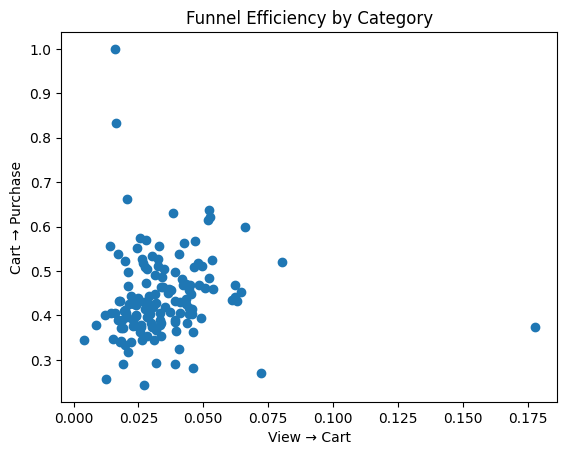

In [18]:
# Categories with:
# high interest but poor checkout
# low engagement but strong conversion

plt.scatter(category_funnel['view_to_cart'], category_funnel['cart_to_purchase'])
plt.xlabel("View → Cart")
plt.ylabel("Cart → Purchase")
plt.title("Funnel Efficiency by Category")
plt.show()

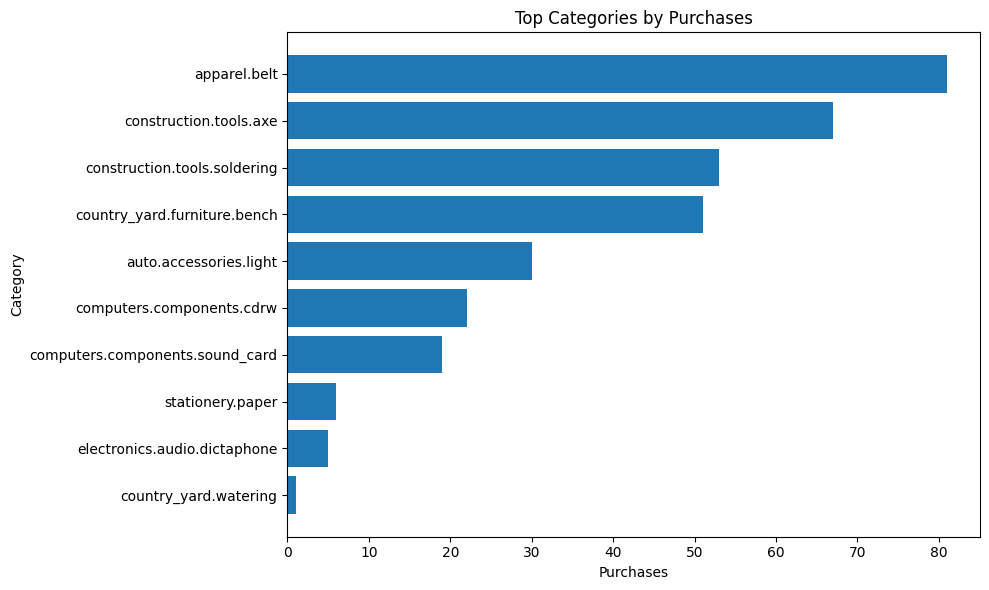

In [30]:
import matplotlib.pyplot as plt

df_sorted = category_funnel.sort_values('purchased', ascending=True).head(10)

plt.figure(figsize=(10,6))
plt.barh(df_sorted['category_code'], df_sorted['purchased'])

plt.title("Top Categories by Purchases")
plt.xlabel("Purchases")
plt.ylabel("Category")

plt.tight_layout()
plt.show()


In [31]:
# --------------------------------------------------
# 4. USER-LEVEL FEATURES (for ML later)
# --------------------------------------------------

user_features = con.execute("""
    SELECT 
        user_id,
        COUNT(*) AS total_events,
        SUM(event_type = 'view') AS views,
        SUM(event_type = 'cart') AS carts,
        SUM(event_type = 'purchase') AS purchases,
        COUNT(DISTINCT product_id) AS unique_products,
        MAX(event_time) - MIN(event_time) AS active_span
    FROM read_parquet('*.parquet')
    GROUP BY user_id
""").df()

print("\n--- User Features Sample ---")
print(user_features.head())



--- User Features Sample ---
     user_id  total_events  views  carts  purchases  unique_products  \
0  513204374           114  114.0    0.0        0.0               41   
1  546357385            25   23.0    2.0        0.0               13   
2  512920308           161  138.0   14.0        9.0               64   
3  535117987           354  348.0    5.0        1.0              152   
4  566417721            40   40.0    0.0        0.0               17   

        active_span  
0 192 days 07:29:48  
1  64 days 13:52:35  
2 149 days 04:58:55  
3 204 days 06:32:33  
4 124 days 23:40:33  


In [32]:
user_features.to_csv("user_level_features.csv", index=False)

In [33]:
# --------------------------------------------------
# 5. SESSION APPROXIMATION (OPTIONAL)
# --------------------------------------------------

sessions = con.execute("""
    SELECT 
        user_id,
        DATE_TRUNC('day', event_time) AS session_day,
        COUNT(*) AS events,
        SUM(event_type = 'purchase') AS purchases
    FROM read_parquet('*.parquet')
    GROUP BY user_id, session_day
""").df()

print("\n--- Sessions Sample ---")
print(sessions.head())


--- Sessions Sample ---
     user_id               session_day  events  purchases
0  518339989 2019-11-01 00:00:00-04:00     137        0.0
1  566444643 2019-11-01 00:00:00-04:00       5        0.0
2  518864616 2019-11-01 00:00:00-04:00      16        1.0
3  532599748 2019-11-01 00:00:00-04:00     167        1.0
4  552822959 2019-11-01 00:00:00-04:00      12        0.0


In [34]:
sessions.to_csv("session_approximation.csv", index=False)